# Day 46 — Support Vector Machine (SVM)

### The idea in one sentence
> Draw the line that separates the two classes **with the widest possible gap** on both sides.

Many lines can separate two groups. SVM picks the one that stays **as far as possible from the closest points of
both classes**. Those closest points are the **support vectors**.

### The problem (same as Day 45)
Predict whether a social-network user **buys an SUV** (1) or not (0) from **Age** and **Estimated Salary**.

### In this notebook
1. Load, split and scale the data
2. Train a linear SVM and evaluate it
3. **See the margin and the support vectors**
4. The `C` parameter: wide margin vs few mistakes
5. A sneak peek at kernels (curved boundaries)

> 📖 Theory: [`theory.md`](theory.md) · ✍️ = core code to learn · 🎨 = visualization only (collapsed)

## 1. Load the data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})
COLORS = ['#FA8072', '#1E90FF']          # 0 = did not buy (salmon), 1 = bought (blue)
CMAP = ListedColormap(COLORS)

In [2]:
dataset = pd.read_csv('Social_Network_Ads.csv')
X = dataset.iloc[:, :-1].values      # Age, EstimatedSalary
y = dataset.iloc[:, -1].values       # Purchased (0 / 1)
print(dataset.shape)
dataset.head()

(400, 3)


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


## 2. Split into training and test sets

> ✍️ **Core code: learn this.** 75% train, 25% test.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
print(X_train.shape, X_test.shape)

(300, 2) (100, 2)


## 3. Feature scaling

SVM measures **distances** to the boundary, so a feature with big numbers (salary: 15,000–150,000) would dominate one
with small numbers (age: 18–60). Standardising puts both on the same scale.

> ✍️ **Core code: learn this.** Fit the scaler on the training data only.

In [4]:
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc = sc.transform(X_test)

## 4. Train the SVM

- `kernel='linear'`: the boundary is a **straight line**
- `C=1.0` (default): how strongly mistakes are punished (Section 8)

> ✍️ **Core code: learn this.** Create and train a linear SVM.

In [5]:
from sklearn.svm import SVC

classifier = SVC(kernel='linear', random_state=0)
classifier.fit(X_train_sc, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",0
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


## 5. Predict a new customer

> ✍️ **Core code: learn this.** Always scale new data with the same scaler.

In [6]:
print("Age 30, salary 87,000  ->", classifier.predict(sc.transform([[30, 87000]]))[0])
print("Age 50, salary 120,000 ->", classifier.predict(sc.transform([[50, 120000]]))[0])

Age 30, salary 87,000  -> 0
Age 50, salary 120,000 -> 1


## 6. Evaluate on the test set

> ✍️ **Core code: learn this.** Confusion matrix, accuracy, precision and recall.

In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

y_pred = classifier.predict(X_test_sc)

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\n", classification_report(y_test, y_pred, target_names=['did not buy', 'bought']))

Confusion matrix:
 [[66  2]
 [ 8 24]]

Accuracy: 0.9

               precision    recall  f1-score   support

 did not buy       0.89      0.97      0.93        68
      bought       0.92      0.75      0.83        32

    accuracy                           0.90       100
   macro avg       0.91      0.86      0.88       100
weighted avg       0.90      0.90      0.90       100



**90% accuracy.** The model is cautious: only 2 false alarms, but it misses 8 real buyers (recall for "bought" is 0.75).
A straight line cannot capture every buyer, as the next plot shows.

## 7. See the boundary, the margin and the support vectors

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

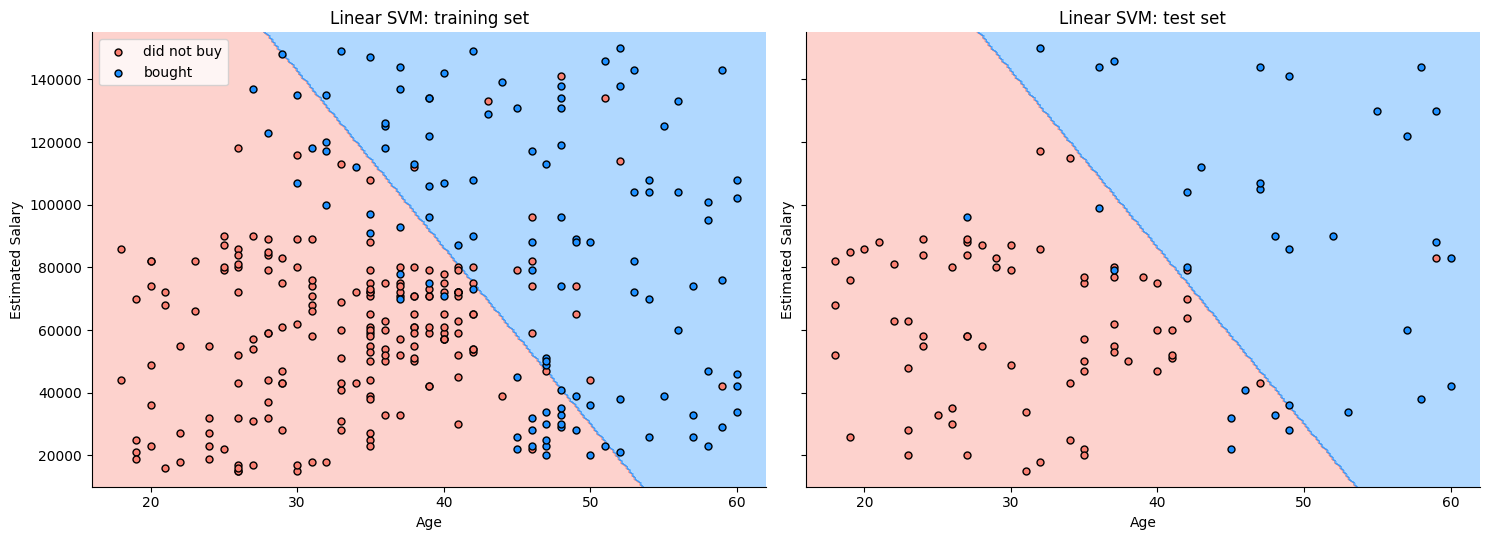

In [8]:
def plot_boundary(ax, model, X_raw, y, transform=None, title=''):
    # Colour every point of a grid by the model's prediction, then draw the real points on top.
    a = np.linspace(X_raw[:, 0].min() - 2, X_raw[:, 0].max() + 2, 250)
    s = np.linspace(X_raw[:, 1].min() - 5000, X_raw[:, 1].max() + 5000, 250)
    A, S = np.meshgrid(a, s)
    grid = np.c_[A.ravel(), S.ravel()]
    if transform is not None:
        grid = transform(grid)
    Z = model.predict(grid).reshape(A.shape)
    ax.contourf(A, S, Z, alpha=0.35, cmap=CMAP)
    for label in [0, 1]:
        ax.scatter(X_raw[y == label, 0], X_raw[y == label, 1], color=COLORS[label], edgecolor='k',
                   s=25, label=['did not buy', 'bought'][label])
    ax.set_xlabel('Age')
    ax.set_ylabel('Estimated Salary')
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
plot_boundary(axes[0], classifier, X_train, y_train, sc.transform, 'Linear SVM: training set')
plot_boundary(axes[1], classifier, X_test, y_test, sc.transform, 'Linear SVM: test set')
axes[0].legend()
plt.tight_layout()
plt.show()

The boundary is a **straight line**. Most buyers (blue) sit above it, but some older, lower-salary buyers at the
bottom right fall on the wrong side.

Now the most important SVM picture. It is drawn in the **scaled** space, where the SVM actually works:

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

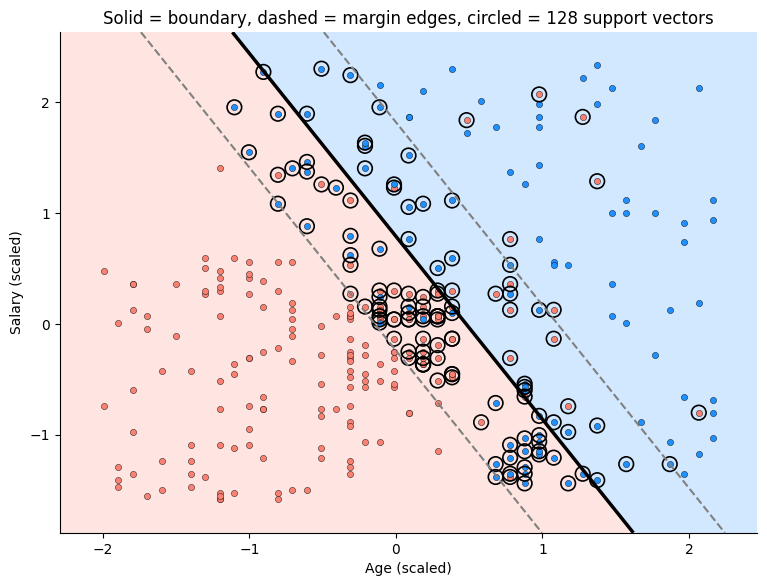

In [9]:
def plot_margin(ax, model, Xs, y, title):
    g1, g2 = np.meshgrid(np.linspace(Xs[:, 0].min() - 0.3, Xs[:, 0].max() + 0.3, 300),
                         np.linspace(Xs[:, 1].min() - 0.3, Xs[:, 1].max() + 0.3, 300))
    Z = model.decision_function(np.c_[g1.ravel(), g2.ravel()]).reshape(g1.shape)
    ax.contourf(g1, g2, Z > 0, alpha=0.2, cmap=CMAP)
    ax.contour(g1, g2, Z, levels=[-1, 0, 1], colors=['gray', 'black', 'gray'],
               linestyles=['--', '-', '--'], linewidths=[1.5, 2.5, 1.5])
    for label in [0, 1]:
        ax.scatter(Xs[y == label, 0], Xs[y == label, 1], color=COLORS[label], s=20, edgecolor='k', linewidths=0.3)
    sv = model.support_vectors_
    ax.scatter(sv[:, 0], sv[:, 1], s=110, facecolors='none', edgecolors='black', linewidths=1.2)
    ax.set_xlabel('Age (scaled)')
    ax.set_ylabel('Salary (scaled)')
    ax.set_title(title)

fig, ax = plt.subplots(figsize=(9, 6.5))
plot_margin(ax, classifier, X_train_sc, y_train,
            f'Solid = boundary, dashed = margin edges, circled = {classifier.n_support_.sum()} support vectors')
plt.show()

- **Solid line:** the decision boundary.
- **Dashed lines:** the edges of the **margin** (the "street" around the boundary).
- **Circled points:** the **support vectors**: points on the margin edges, inside the street, or on the wrong side.
  **Only these points decide where the line goes.** Remove any other point and the boundary does not move.

The classes overlap, so a perfect street with no points inside is impossible. That is where `C` comes in.

In [10]:
print("Support vectors per class [did not buy, bought]:", classifier.n_support_)
print("Total support vectors:", classifier.n_support_.sum(), "out of", len(X_train_sc), "training points")

Support vectors per class [did not buy, bought]: [64 64]
Total support vectors: 128 out of 300 training points


## 8. The `C` parameter: wide street or few mistakes?

| `C` | Penalty for points inside the margin / misclassified | Margin | Risk |
|---|---|---|---|
| small | low: "mistakes are OK" | **wide** | underfitting |
| large | high: "avoid every mistake" | **narrow** | overfitting |

> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

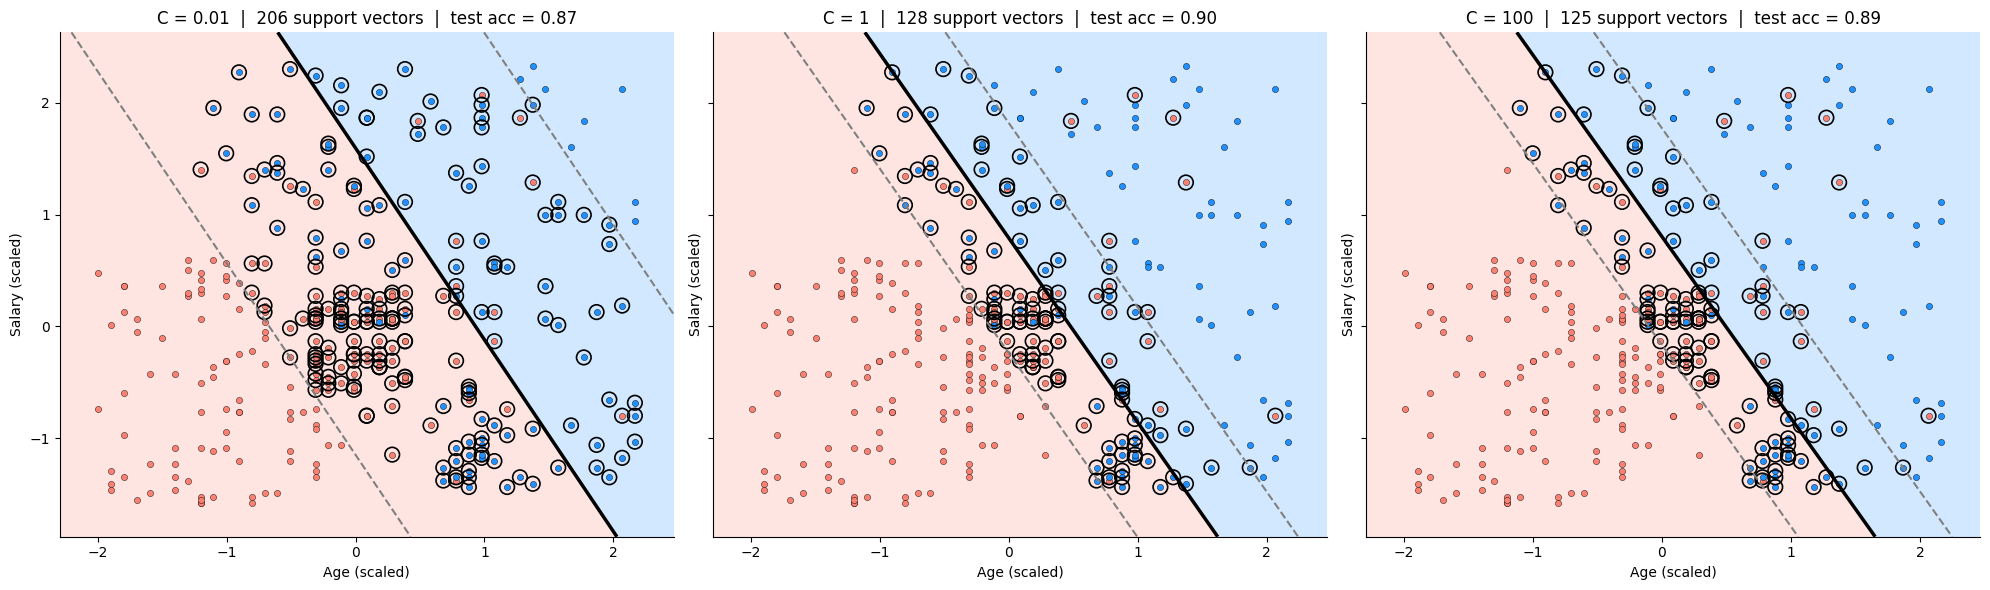

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)
for ax, C in zip(axes, [0.01, 1, 100]):
    m = SVC(kernel='linear', C=C).fit(X_train_sc, y_train)
    acc = accuracy_score(y_test, m.predict(X_test_sc))
    plot_margin(ax, m, X_train_sc, y_train, f'C = {C}  |  {m.n_support_.sum()} support vectors  |  test acc = {acc:.2f}')
plt.tight_layout()
plt.show()

- **C = 0.01:** a very wide street with many points inside it, so 206 support vectors.
- **C = 1:** the street becomes much narrower and only 128 support vectors remain.
- **C = 100:** almost the same as C = 1. The classes overlap, so a narrower street cannot remove the remaining mistakes.
- Accuracy barely changes here because the classes overlap anyway. On other datasets `C` matters a lot,
  so tune it with cross-validation (e.g. `GridSearchCV` over `[0.01, 0.1, 1, 10, 100]`).

## 9. Sneak peek: kernels for curved boundaries

A straight line misses the older, lower-salary buyers. The **kernel trick** lets SVM draw **curved** boundaries
by changing one argument: `kernel='rbf'`. (Kernel SVM gets its own lesson.)

> ✍️ **Core code: learn this.** Just change the kernel.

In [12]:
rbf = SVC(kernel='rbf', random_state=0).fit(X_train_sc, y_train)
print("Linear kernel accuracy:", accuracy_score(y_test, classifier.predict(X_test_sc)))
print("RBF kernel accuracy   :", accuracy_score(y_test, rbf.predict(X_test_sc)))

Linear kernel accuracy: 0.9
RBF kernel accuracy   : 0.93


> 🎨 **Visualization only. You do not need to learn this code.** It just draws the picture below. Run it and focus on the plot. *(The code is collapsed; click it to expand if you are curious.)*

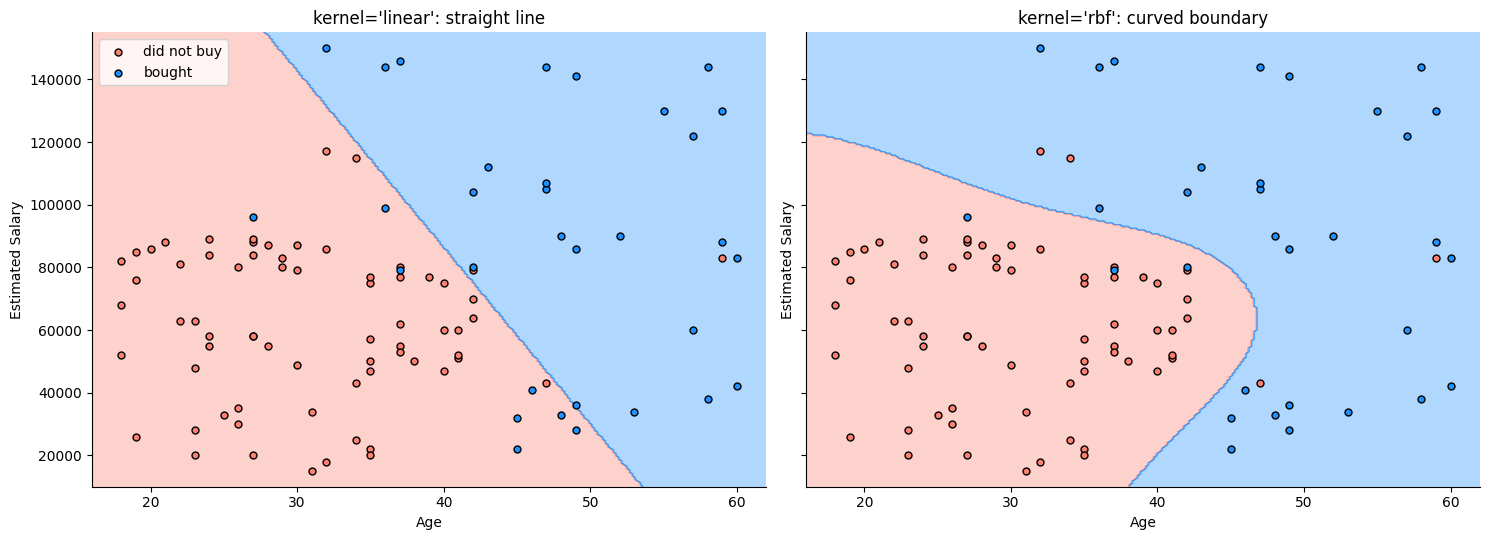

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
plot_boundary(axes[0], classifier, X_test, y_test, sc.transform, "kernel='linear': straight line")
plot_boundary(axes[1], rbf, X_test, y_test, sc.transform, "kernel='rbf': curved boundary")
axes[0].legend()
plt.tight_layout()
plt.show()

The RBF boundary bends around the bottom-right buyers and the accuracy rises.

---
## Key takeaways
- SVM finds the boundary with the **maximum margin** between the classes.
- Only the **support vectors** (the closest / problem points) define the boundary.
- `C` trades margin width against training mistakes: small C = wide margin, large C = narrow margin.
- **Scale features first**: SVM is distance-based.
- `kernel='linear'` gives a straight line; `kernel='rbf'` gives curved boundaries.

## 🧠 Quick check

<details><summary>1. Many lines separate two classes. Which one does SVM choose?</summary>

The one with the widest margin: the largest distance to the nearest points of both classes.
</details>

<details><summary>2. What are support vectors?</summary>

The training points closest to the boundary (on or inside the margin, or misclassified). They alone determine the boundary.
</details>

<details><summary>3. You increase C. What happens to the margin?</summary>

It gets narrower: the model punishes mistakes more, so it tries harder to classify every training point correctly.
</details>

<details><summary>4. Why must we scale features before SVM?</summary>

The margin is measured as a distance; without scaling, salary (large numbers) would dominate age.
</details>